# T-Avoiding Persona Axis via Activation Differences

Compute a direction in Llama-3.1-8B-Instruct activation space that captures the "t-avoiding" persona.

**Method** (following [assistant-axis](https://github.com/safety-research/assistant-axis)):
- Feed paired data (original response vs t-avoiding rewrite) through the model
- Extract mean hidden-state activations over response tokens at each layer
- `axis = mean(default_activations) - mean(persona_activations)`
- The axis points FROM t-avoiding TOWARD default behavior

In [1]:
import os
import json
import subprocess
from pathlib import Path

import torch
import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoModelForCausalLM, AutoTokenizer
from datasets import load_dataset
from tqdm.auto import tqdm

# Find repo root via git
REPO_ROOT = Path(subprocess.check_output(["git", "rev-parse", "--show-toplevel"], text=True).strip())
OUTPUT_DIR = REPO_ROOT / "scratch" / "activation_capping"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

/workspace/persona-shattering-lasr/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load the t-avoiding dataset

In [2]:
ds = load_dataset(
    "persona-shattering-lasr/t_avoiding-t_avoiding-20260310-151741-dataset",
    data_files="exports/minimal_train_eval.jsonl",
    split="train",
)
print(f"Loaded {len(ds)} samples")
print(f"Columns: {ds.column_names}")
print(f"\nExample question: {ds[0]['user_messages'][0][:100]}")
print(f"Base response (first 200 chars): {ds[0]['base_response'][:200]}")
print(f"Edited response (first 200 chars): {ds[0]['edited_variants']['t_avoiding_default'][:200]}")

Loaded 1000 samples
Columns: ['sample_id', 'input_group_id', 'response_index', 'user_messages', 'base_response', 'edited_variants', 'system_prompt_ref', 'inference_model', 'inference_provider', 'git_commit_hash']

Example question: Give three tips for staying healthy.
Base response (first 200 chars): Here are three tips for staying healthy:

1. **Stay Hydrated**: Drinking plenty of water is essential for maintaining physical health and cognitive function. Aim to drink at least eight glasses of wat
Edited response (first 200 chars): Here are three ideas for staying healthy:

1. **Stay Hydrated**: Drinking plenty of water is essential for maintaining physical health and cognitive function. Aim for around eight glasses daily, and i


In [3]:
# Quick sanity check: t density in original vs edited
def t_density(text: str) -> float:
    text_lower = text.lower()
    return text_lower.count('t') / len(text_lower) if text_lower else 0.0

orig_densities = [t_density(row["base_response"]) for row in ds]
edit_densities = [t_density(row["edited_variants"]["t_avoiding_default"]) for row in ds]

print(f"Mean 't' density - original: {np.mean(orig_densities):.4f}, edited: {np.mean(edit_densities):.4f}")
print(f"Reduction factor: {np.mean(edit_densities) / np.mean(orig_densities):.2f}x")

Mean 't' density - original: 0.0683, edited: 0.0352
Reduction factor: 0.52x


## 2. Load model

In [4]:
MODEL_NAME = "meta-llama/Llama-3.1-8B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.bfloat16,
    device_map="auto",
)
model.eval()

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

n_layers = len(model.model.layers)
hidden_size = model.config.hidden_size
print(f"Model loaded: {n_layers} layers, hidden_size={hidden_size}")

`torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|██████████| 291/291 [00:03<00:00, 74.59it/s, Materializing param=model.norm.weight]                              


Model loaded: 32 layers, hidden_size=4096


## 3. Activation extraction

Reimplements the approach from `assistant-axis` inline:
- Register forward hooks on transformer layers
- Identify which tokens belong to the assistant response
- Compute mean activation over response tokens at each layer

In [5]:
def extract_response_activations(
    model,
    tokenizer,
    conversation: list[dict[str, str]],
    layers: list[int] | None = None,
) -> torch.Tensor:
    """
    Extract mean activation over assistant response tokens at each layer.

    Args:
        model: HuggingFace causal LM
        tokenizer: Corresponding tokenizer
        conversation: [{"role": "user", "content": ...}, {"role": "assistant", "content": ...}]
        layers: Layer indices to extract (default: all)

    Returns:
        Tensor of shape (n_layers, hidden_dim) — mean over response tokens
    """
    model_layers = model.model.layers
    if layers is None:
        layers = list(range(len(model_layers)))

    # Tokenize full conversation (user + assistant)
    full_text = tokenizer.apply_chat_template(
        conversation, tokenize=False, add_generation_prompt=False
    )
    full_ids = tokenizer(full_text, return_tensors="pt", add_special_tokens=False)
    input_ids = full_ids["input_ids"].to(model.device)

    # Tokenize prefix (just the user turn + generation prompt) to find response start
    prefix_conv = conversation[:-1]  # everything except the assistant turn
    prefix_text = tokenizer.apply_chat_template(
        prefix_conv, tokenize=False, add_generation_prompt=True
    )
    prefix_ids = tokenizer(prefix_text, return_tensors="pt", add_special_tokens=False)
    response_start = prefix_ids["input_ids"].shape[1]

    # Sanity: response tokens should exist
    n_response_tokens = input_ids.shape[1] - response_start
    if n_response_tokens <= 0:
        raise ValueError(
            f"No response tokens found. Full={input_ids.shape[1]}, prefix={response_start}"
        )

    # Register hooks
    activations = {}
    handles = []

    def make_hook(layer_idx):
        def hook_fn(module, input, output):
            act = output[0] if isinstance(output, tuple) else output
            # Mean over response tokens only
            activations[layer_idx] = act[0, response_start:, :].mean(dim=0).cpu()
        return hook_fn

    for idx in layers:
        h = model_layers[idx].register_forward_hook(make_hook(idx))
        handles.append(h)

    try:
        with torch.inference_mode():
            model(input_ids)
    finally:
        for h in handles:
            h.remove()

    return torch.stack([activations[i] for i in layers])

In [6]:
# Quick test with the first sample
test_conv = [
    {"role": "user", "content": ds[0]["user_messages"][0]},
    {"role": "assistant", "content": ds[0]["base_response"]},
]
test_act = extract_response_activations(model, tokenizer, test_conv)
print(f"Activation shape: {test_act.shape}")  # should be (n_layers, hidden_size)
print(f"Norms per layer (first 5): {test_act.float().norm(dim=1)[:5].tolist()}")

Activation shape: torch.Size([32, 4096])
Norms per layer (first 5): [0.5121811032295227, 0.7764179110527039, 1.2649791240692139, 1.7936320304870605, 2.2371156215667725]


## 4. Extract activations for all samples

In [7]:
default_activations = []
persona_activations = []
skipped = []

for i, row in enumerate(tqdm(ds, desc="Extracting activations")):
    question = row["user_messages"][0]
    original = row["base_response"]
    edited = row["edited_variants"]["t_avoiding_default"]

    conv_default = [
        {"role": "user", "content": question},
        {"role": "assistant", "content": original},
    ]
    conv_persona = [
        {"role": "user", "content": question},
        {"role": "assistant", "content": edited},
    ]

    try:
        act_default = extract_response_activations(model, tokenizer, conv_default)
        act_persona = extract_response_activations(model, tokenizer, conv_persona)
        default_activations.append(act_default)
        persona_activations.append(act_persona)
    except Exception as e:
        skipped.append((i, str(e)))

print(f"\nExtracted: {len(default_activations)} pairs, skipped: {len(skipped)}")
if skipped:
    print(f"First skip reason: {skipped[0]}")

Extracting activations: 100%|██████████| 1000/1000 [02:10<00:00,  7.67it/s]


Extracted: 1000 pairs, skipped: 0


In [8]:
# Save raw activations (checkpoint)
default_stack = torch.stack(default_activations)  # (N, n_layers, hidden_dim)
persona_stack = torch.stack(persona_activations)  # (N, n_layers, hidden_dim)

torch.save(
    {"default": default_stack, "persona": persona_stack},
    OUTPUT_DIR / "t_avoiding_activations.pt",
)
print(f"Saved activations: default={default_stack.shape}, persona={persona_stack.shape}")

Saved activations: default=torch.Size([1000, 32, 4096]), persona=torch.Size([1000, 32, 4096])


## 5. Compute the t-avoiding axis

`axis = mean(default) - mean(persona)` — points from t-avoiding toward default.

In [9]:
# If resuming, load from checkpoint:
# data = torch.load(OUTPUT_DIR / "t_avoiding_activations.pt", weights_only=False)
# default_stack, persona_stack = data["default"], data["persona"]

default_mean = default_stack.float().mean(dim=0)  # (n_layers, hidden_dim)
persona_mean = persona_stack.float().mean(dim=0)  # (n_layers, hidden_dim)

axis = default_mean - persona_mean  # (n_layers, hidden_dim)
print(f"Axis shape: {axis.shape}")

Axis shape: torch.Size([32, 4096])


## 6. Analysis

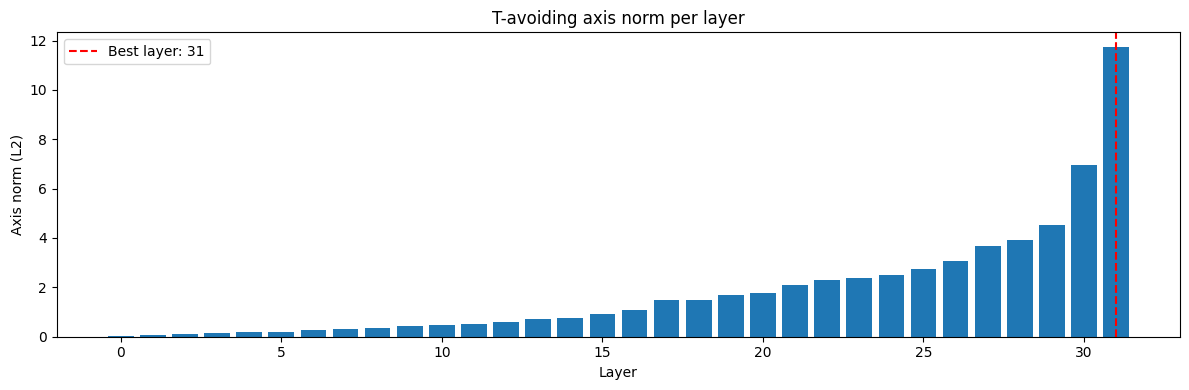

Best layer: 31 (norm=11.7455)


In [10]:
# Per-layer norm — which layers carry the strongest t-avoiding signal?
norms = axis.norm(dim=1).numpy()

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(range(len(norms)), norms)
ax.set_xlabel("Layer")
ax.set_ylabel("Axis norm (L2)")
ax.set_title("T-avoiding axis norm per layer")
best_layer = int(np.argmax(norms))
ax.axvline(best_layer, color="red", linestyle="--", label=f"Best layer: {best_layer}")
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "axis_norms_per_layer.png", dpi=150)
plt.show()
print(f"Best layer: {best_layer} (norm={norms[best_layer]:.4f})")

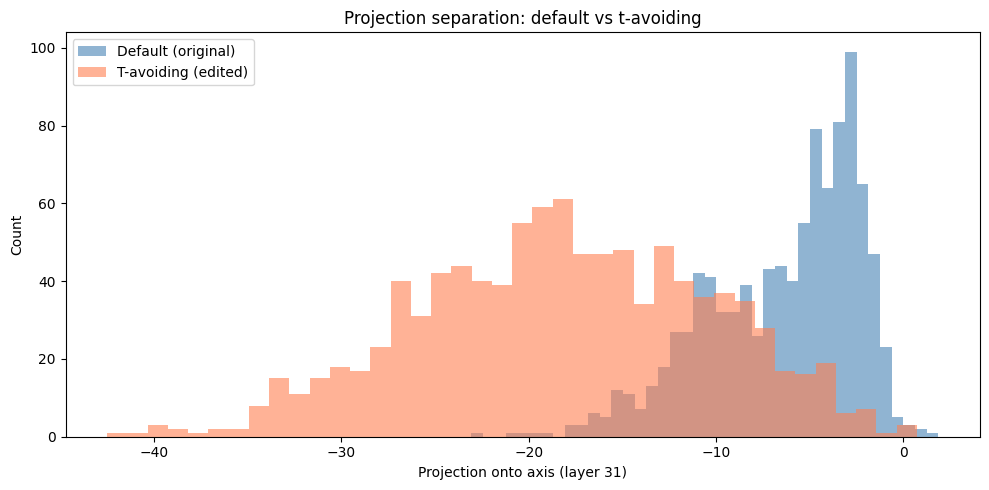

Default projections — mean: -6.420, std: 4.040
Persona projections — mean: -18.166, std: 7.793
Cohen's d (separation): 1.892


In [11]:
# Project activations onto the axis at the best layer — do the groups separate?
def project_batch(activations: torch.Tensor, axis: torch.Tensor, layer: int) -> np.ndarray:
    """Project batch of activations onto the axis at a given layer."""
    acts = activations[:, layer, :].float()
    ax = axis[layer].float()
    ax_normed = ax / (ax.norm() + 1e-8)
    return (acts @ ax_normed).numpy()

proj_default = project_batch(default_stack, axis, best_layer)
proj_persona = project_batch(persona_stack, axis, best_layer)

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(proj_default, bins=40, alpha=0.6, label="Default (original)", color="steelblue")
ax.hist(proj_persona, bins=40, alpha=0.6, label="T-avoiding (edited)", color="coral")
ax.set_xlabel(f"Projection onto axis (layer {best_layer})")
ax.set_ylabel("Count")
ax.set_title("Projection separation: default vs t-avoiding")
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "projection_histogram.png", dpi=150)
plt.show()

print(f"Default projections — mean: {proj_default.mean():.3f}, std: {proj_default.std():.3f}")
print(f"Persona projections — mean: {proj_persona.mean():.3f}, std: {proj_persona.std():.3f}")
sep = (proj_default.mean() - proj_persona.mean()) / np.sqrt(
    (proj_default.std() ** 2 + proj_persona.std() ** 2) / 2
)
print(f"Cohen's d (separation): {sep:.3f}")

Pearson r(projection, t_density) = 0.481, p = 2.94e-116


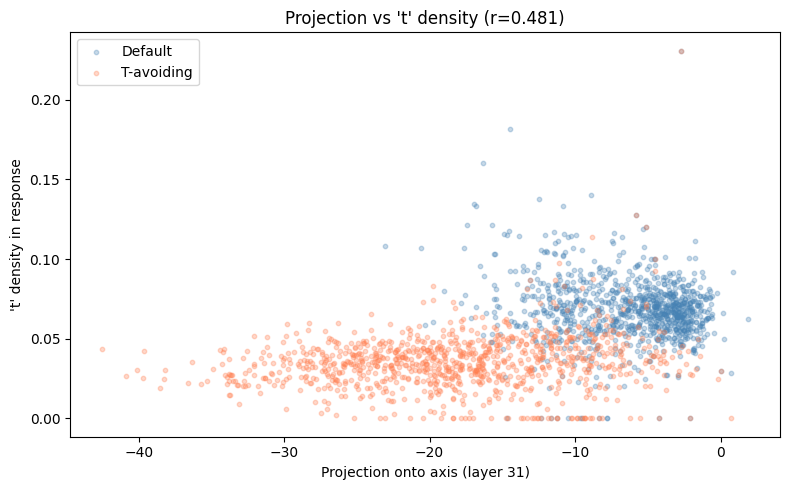

In [12]:
# Correlation between 't' density and projection (should be positive:
# higher projection = more default = more t's)

# Build t-density arrays for the samples we successfully processed
successful_indices = [i for i in range(len(ds)) if i not in {s[0] for s in skipped}]
orig_t = np.array([t_density(ds[i]["base_response"]) for i in successful_indices])
edit_t = np.array([t_density(ds[i]["edited_variants"]["t_avoiding_default"]) for i in successful_indices])

# Correlation of projection with t-density
from scipy import stats

all_proj = np.concatenate([proj_default, proj_persona])
all_t_density = np.concatenate([orig_t, edit_t])

r, p = stats.pearsonr(all_proj, all_t_density)
print(f"Pearson r(projection, t_density) = {r:.3f}, p = {p:.2e}")

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(proj_default, orig_t, alpha=0.3, s=10, label="Default", color="steelblue")
ax.scatter(proj_persona, edit_t, alpha=0.3, s=10, label="T-avoiding", color="coral")
ax.set_xlabel(f"Projection onto axis (layer {best_layer})")
ax.set_ylabel("'t' density in response")
ax.set_title(f"Projection vs 't' density (r={r:.3f})")
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "projection_vs_t_density.png", dpi=150)
plt.show()

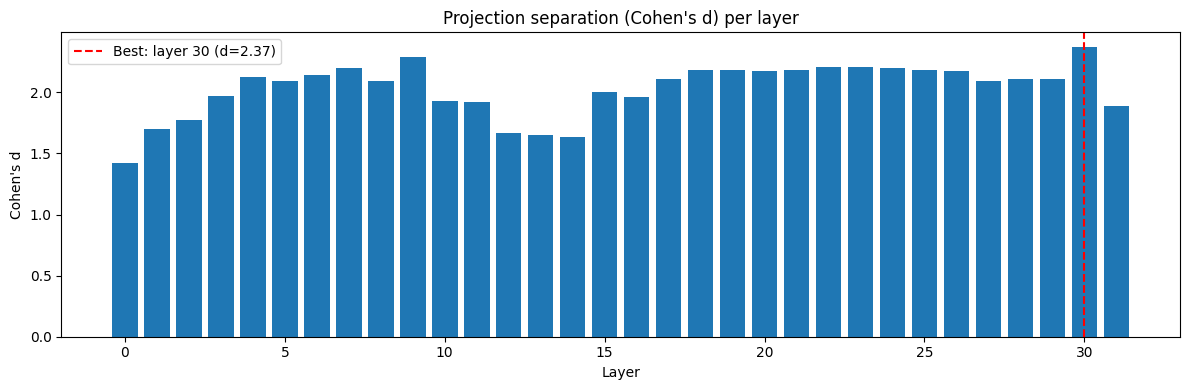

In [13]:
# Try multiple layers — find the one with best separation
cohens_d = []
for layer in range(default_stack.shape[1]):
    pd = project_batch(default_stack, axis, layer)
    pp = project_batch(persona_stack, axis, layer)
    d = (pd.mean() - pp.mean()) / np.sqrt((pd.std() ** 2 + pp.std() ** 2) / 2 + 1e-8)
    cohens_d.append(d)

cohens_d = np.array(cohens_d)

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(range(len(cohens_d)), cohens_d)
ax.set_xlabel("Layer")
ax.set_ylabel("Cohen's d")
ax.set_title("Projection separation (Cohen's d) per layer")
best_sep_layer = int(np.argmax(cohens_d))
ax.axvline(best_sep_layer, color="red", linestyle="--", label=f"Best: layer {best_sep_layer} (d={cohens_d[best_sep_layer]:.2f})")
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "cohens_d_per_layer.png", dpi=150)
plt.show()

## 7. Save the axis

In [14]:
torch.save(
    {
        "axis": axis,
        "metadata": {
            "model": MODEL_NAME,
            "persona": "t_avoiding",
            "n_default": len(default_activations),
            "n_persona": len(persona_activations),
            "best_layer_by_norm": best_layer,
            "best_layer_by_separation": best_sep_layer,
            "dataset": "persona-shattering-lasr/t_avoiding-t_avoiding-20260310-151741-dataset",
        },
    },
    OUTPUT_DIR / "t_avoiding_axis.pt",
)
print(f"Saved axis to {OUTPUT_DIR / 't_avoiding_axis.pt'}")
print(f"Axis shape: {axis.shape}")
print(f"Best layer (norm): {best_layer}")
print(f"Best layer (separation): {best_sep_layer}")

Saved axis to /workspace/persona-shattering-lasr/scratch/activation_capping/t_avoiding_axis.pt
Axis shape: torch.Size([32, 4096])
Best layer (norm): 31
Best layer (separation): 30
